# PMOIRED tutorial: simulating VLTI/PIONIER binary data

In this tutorial, we generate synthetic VLTI/PIONIER observables for a binary star to see what to expect from real data. No model fitting is done here.

*This is similar to PMOIRED example #4, where VLTI/GRAVITY data are generated.*

In [15]:
# -- uncomment to get interactive plots
# %matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt

import pmoired
print('PMOIRED version:', pmoired.__version__)

PMOIRED version: 1.3.11


**Define one binary model and generate both clean and noisy synthetic data using pmoired.oifake.**

You can change `selected_configs`, `model_true`, `wl`, `lst`, or `noise_pionier` to explore how the synthetic signatures change.

In [28]:
# -- PIONIER H-band setup
wl = np.linspace(1.53, 1.77, 8)   # wavelength [um]
lst = np.linspace(18.0, 18.5, 1)  # local sidereal time [hours]

print('Selected wavelengths [um]:', wl)
print('Selected LST samples [hours]:', lst)
print(f'N_wavelength_channels = {len(wl)}, N_time_samples = {len(lst)}')

# -- fixed target coordinates (RA [hours], Dec [deg])
target = (17.5, -50.0)

# -- VLTI AT station sets often used with PIONIER
pionier_configs = {
    'small':    {'stations': ['A0', 'B2', 'C1', 'D0'], 'doubleDL': False},
    'medium':   {'stations': ['A0', 'B5', 'D0', 'G1'], 'doubleDL': False},
    'large':    {'stations': ['G1', 'A0', 'J3', 'J2'], 'doubleDL': False}, # the order matters here for the T3PHI sign
    'extended': {'stations': ['A0', 'B5', 'J2', 'J6'], 'doubleDL': True},
}
selected_configs = ['large']

# -- true binary model in PMOIRED syntax
model_true = {
    'A,ud': 0.5,
    'A,f': 1.0,
    'B,ud': 0.1,
    'B,f': 0.03,
    'B,x': -4.5,
    'B,y': -4.8,
}


# -- three noisy setups
noise_setups = {
    'less_noisy': {
        'V2': 0.01,
        'T3PHI': 0.25,
    },
    'noisy': {
        'V2': .02,
        'T3PHI': 0.5,
    },
    'more_noisy': {
        'V2': 0.04,
        'T3PHI': 1.0,
    },
}

print('\nNoise setups:')
for name, ns in noise_setups.items():
    print(f'  {name}: V2={ns["V2"]}, T3PHI={ns["T3PHI"]} deg')

def make_synthetic(config_name, noise, random_seed=0):
    cfg = pionier_configs[config_name]
    common = dict(
        t=cfg['stations'],
        target=target,
        lst=lst,
        wl=wl,
        model=model_true,
        insname=f'PIONIER_{config_name}',
        doubleDL=cfg['doubleDL'],
    )
    np.random.seed(random_seed)
    return pmoired.oifake.makeFakeVLTI(noise=noise, **common)

sim_data = {}
for i, cfg_name in enumerate(selected_configs):
    clean = make_synthetic(cfg_name, noise=0, random_seed=100 + 10 * i)
    sim_data[cfg_name] = {'clean': clean, 'noisy_setups': {}}

    for j, (noise_name, noise_cfg) in enumerate(noise_setups.items()):
        noisy = make_synthetic(cfg_name, noise=noise_cfg, random_seed=100 + 10 * i + j + 1)
        sim_data[cfg_name]['noisy_setups'][noise_name] = noisy

    # Summary from one noisy setup (shape identical across noisy levels)
    example_noisy = sim_data[cfg_name]['noisy_setups']['noisy']
    n_baselines = len(example_noisy['OI_VIS2'])
    n_triangles = len(example_noisy['OI_T3'])
    n_exposures = len(example_noisy['MJD'])
    n_wl = len(example_noisy['WL'])

    print(f'\nConfiguration: {cfg_name}')
    print(f'  Baselines: {n_baselines}, Triangles: {n_triangles}')
    print(f'  Points per dataset: V2={n_baselines * n_exposures * n_wl}, T3PHI={n_triangles * n_exposures * n_wl}')

    # Diagnostic: each baseline has (N_time_samples, N_wavelength_channels)
    b0 = next(iter(example_noisy['OI_VIS2']))
    print(f'  Example baseline {b0}: V2 array shape = {example_noisy["OI_VIS2"][b0]["V2"].shape} (N_lst, N_wl)')

print('\nModel:', model_true)


Selected wavelengths [um]: [1.53       1.56428571 1.59857143 1.63285714 1.66714286 1.70142857
 1.73571429 1.77      ]
Selected LST samples [hours]: [18.]
N_wavelength_channels = 8, N_time_samples = 1

Noise setups:
  less_noisy: V2=0.01, T3PHI=0.25 deg
  noisy: V2=0.02, T3PHI=0.5 deg
  more_noisy: V2=0.04, T3PHI=1.0 deg

Configuration: large
  Baselines: 6, Triangles: 4
  Points per dataset: V2=48, T3PHI=32
  Example baseline G1A0: V2 array shape = (1, 8) (N_lst, N_wl)

Model: {'A,ud': 0.5, 'A,f': 1.0, 'B,ud': 0.1, 'B,f': 0.03, 'B,x': -4.5, 'B,y': -4.8}


**Display uv coverage and synthetic observables (clean and noisy)**

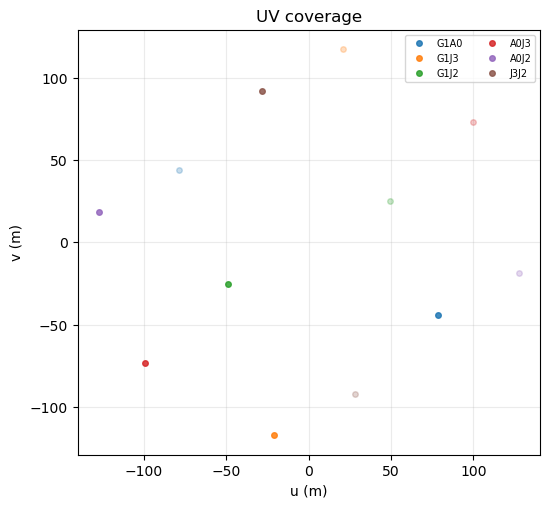

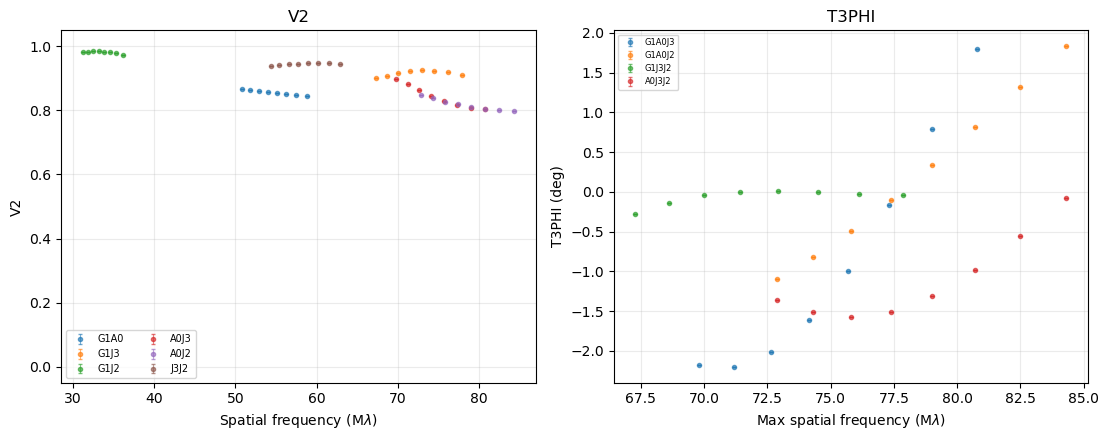

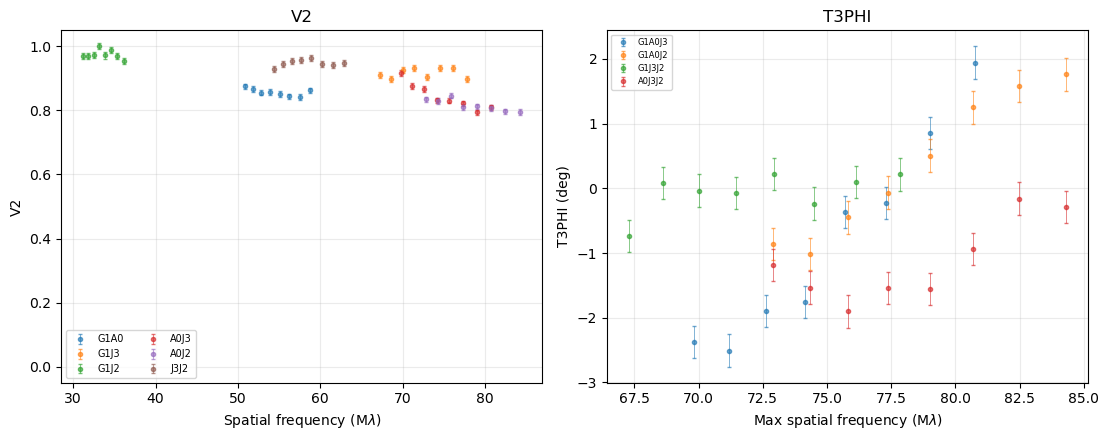

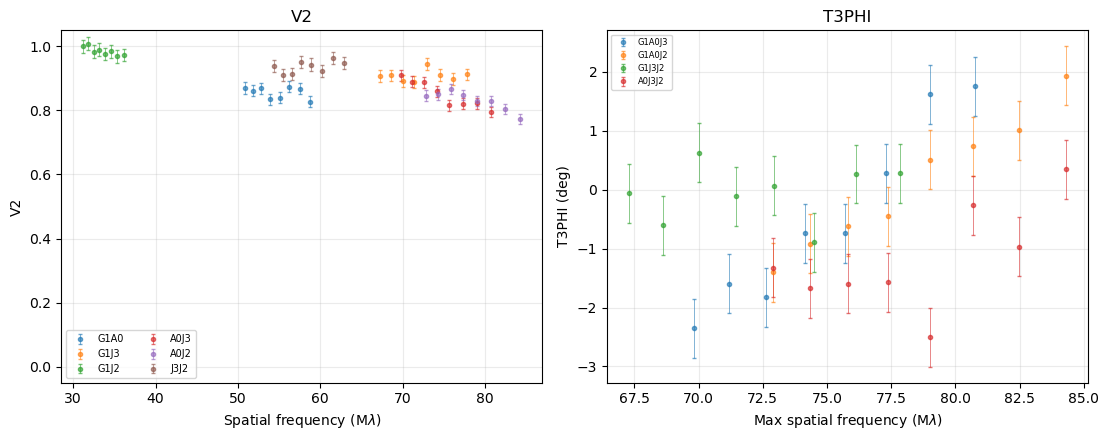

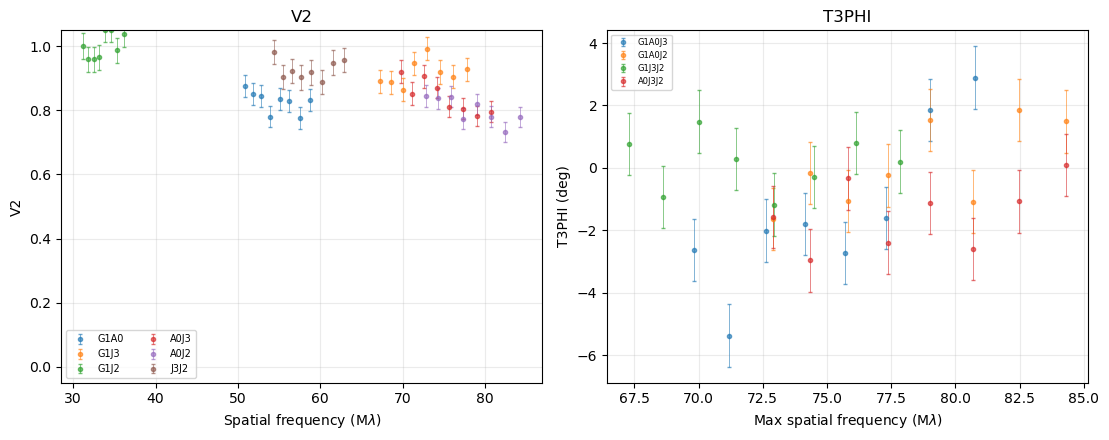

In [38]:
# -- internal fixed color sets (kept static on purpose)
_baseline_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
_triangle_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

def plot_uv(data):
    fig, ax = plt.subplots(1, 1, figsize=(5.6, 5.2))
    for i, (baseline, d) in enumerate(data['OI_VIS2'].items()):
        color = _baseline_colors[i % len(_baseline_colors)]
        ax.plot(d['u'], d['v'], 'o', ms=4, alpha=0.85, color=color, label=baseline)
        ax.plot(-d['u'], -d['v'], 'o', ms=4, alpha=0.25, color=color)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('u (m)')
    ax.set_ylabel('v (m)')
    ax.set_title('UV coverage')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()

def plot_v2_t3phi(data, with_errors=True):
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))

    # -- V2
    for i, (baseline, d) in enumerate(data['OI_VIS2'].items()):
        color = _baseline_colors[i % len(_baseline_colors)]
        x = d['B/wl'].ravel()  # already in Mlambda (10^6 lambda)
        y = d['V2'].ravel()
        e = d['EV2'].ravel()
        if with_errors:
            axes[0].errorbar(
                x, y, yerr=e, fmt='o', ms=3, alpha=0.65, lw=0.6, capsize=1.5,
                color=color, ecolor=color, label=baseline
            )
        else:
            axes[0].scatter(x, y, s=14, alpha=0.7, color=color, label=baseline)

    axes[0].set_xlabel('Spatial frequency (M$\lambda$)')
    axes[0].set_ylabel('V2')
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].set_title('V2')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=7, ncol=2)

    # -- T3PHI: use the 4-color list directly (one color per triangle)
    for i, (tri, d) in enumerate(data['OI_T3'].items()):
        color = _triangle_colors[i % len(_triangle_colors)]
        s, tri_baselines, w0, w1, w2 = d['formula']
        w0 = np.asarray(w0, dtype=int)
        w1 = np.asarray(w1, dtype=int)
        w2 = np.asarray(w2, dtype=int)

        b1_wl = data['OI_VIS2'][tri_baselines[0]]['B/wl'][w0, :]
        b2_wl = data['OI_VIS2'][tri_baselines[1]]['B/wl'][w1, :]
        b3_wl = data['OI_VIS2'][tri_baselines[2]]['B/wl'][w2, :]

        x = np.maximum.reduce([b1_wl, b2_wl, b3_wl]).ravel()  # in Mlambda (10^6 lambda)
        y = d['T3PHI'].ravel()
        e = d['ET3PHI'].ravel()
        label = tri

        if with_errors:
            axes[1].errorbar(
                x, y, yerr=e, fmt='o', ms=3, alpha=0.65, lw=0.6, capsize=1.5,
                color=color, ecolor=color, label=label
            )
        else:
            axes[1].scatter(x, y, s=14, alpha=0.7, color=color, label=label)

    axes[1].set_xlabel('Max spatial frequency (M$\lambda$)')
    axes[1].set_ylabel('T3PHI (deg)')
    axes[1].set_title('T3PHI')
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=6, loc='best')

    fig.tight_layout()
    plt.show()

cfg_name = selected_configs[0]
clean = sim_data[cfg_name]['clean']
noisy_setups = sim_data[cfg_name]['noisy_setups']

# -- plot UV coverage once
plot_uv(clean)

# -- clean reference
plot_v2_t3phi(clean, with_errors=True)

# -- then plot all three noisy setups
label_map = {
    'less_noisy': 'less noisy',
    'noisy': 'noisy',
    'more_noisy': 'more noisy',
}
for key in ['less_noisy', 'noisy', 'more_noisy']:
    plot_v2_t3phi(
        noisy_setups[key],
        with_errors=True,
    )
